# Final Project

### Environment and Imports

In [ ]:
## Instructions for Google Colab. You can ignore this cell if you have cuda-q set up and have
# all the dependent files on your system
# Run this notebook in a CPU runtime
# Uncomment the lines below and execute the cell to install cuda-q

!pip install cudaq

!wget -q https://github.com/nvidia/cuda-q-academic/archive/refs/heads/main.zip
!unzip -q main.zip
!mv cuda-q-academic-main/quantum-applications-to-finance/images ./images

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.9/404.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.4/227.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 MB 4.9 MB/s eta 0:00:

In [ ]:
import cudaq
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt

### Quantum Walks

In [ ]:
# Define kernels to prevent transitions between |0000> and |1111>

# Kernel to change a coin from 1 to 0 if the walker is the state |1111>
@cudaq.kernel
def no_INC_at_right_endpoint(walker_qubits : cudaq.qvector, coin_qubit : cudaq.qubit, right_endpoint : cudaq.qubit):

    # Test if the coin is in |1> and the walker state is |1111>,  if so, change the end_point qubit to 1
    x.ctrl([coin_qubit, walker_qubits[0], walker_qubits[1], walker_qubits[2], walker_qubits[3]], right_endpoint)

    # Flip the state of the coin if the endpoint is triggered
    x.ctrl(right_endpoint, coin_qubit)


# Kernel to change a coin from 0 to 1 if the walker is in the state |0000>
@cudaq.kernel
def no_DEC_at_left_endpoint(walker_qubits : cudaq.qvector, coin_qubit : cudaq.qubit, left_endpoint : cudaq.qubit):
    # Bit Flip the walker and coin qubits
    x(coin_qubit)
    x(walker_qubits)

    # Trigger the left_endpoint qubit if the walker and the coin are now in the states |1> and |1111> respectively
    x.ctrl([coin_qubit, walker_qubits[0], walker_qubits[1], walker_qubits[2], walker_qubits[3]], left_endpoint)

    # Undo the bit flip on the walker and coin qubits
    x(walker_qubits)
    x(coin_qubit)

    # Flip the coin fron |0> to |1> if the endpoint qubit is triggered
    x.ctrl(left_endpoint,coin_qubit)

# Kernel to reset the coin and endpoint qubit
@cudaq.kernel()
def reset_coin_and_endpoint(coin_qubit : cudaq.qubit, endpoint: cudaq.qubit):
    # change the coin qubit back if it was flipped to prevent transitions
    # between |0000> and |1111>
    x.ctrl(endpoint, coin_qubit)

    # reset the endpoint qubit to |0>
    reset(endpoint)

@cudaq.kernel
def initial_position(qubits : cudaq.qvector):
    """ Apply gates to the qubits to prepare the GHZ state
    Parameters
        qubits: cudaq.qvector
        qubits for the walker
    """
    #Prepare (|0010> + |0011>) / sqrt(2)

    #Set base state |0010>
    x(qubits[1])  #flip qubit 1

    #Create superposition on last qubit
    h(qubits[3])

# Define a kernel on 4 qubits for the inc operation that
# maps |x> to |x+1> mod 16
num_qubits = 4

@cudaq.kernel
def inc(qubits : cudaq.qview):
    x.ctrl([qubits[3], qubits[2], qubits[1]], qubits[0])
    x.ctrl([qubits[3], qubits[2]], qubits[1])
    x.ctrl(qubits[3], qubits[2])
    x(qubits[3])

# Define a kernel on 4 qubits for the dec operation that
# maps |x> to |x-1> mod 16
@cudaq.kernel
def dec(qubits : cudaq.qview):
    cudaq.adjoint(inc, qubits)

In [ ]:
def plot_walk_results(result, num_qubits, title):
    """Function that plots a historgram of the results of a quantum walk

    Parameters
    ----------
    results: cudaq.SampleResult
        results dictionary of sampling a quantum walk
    num_qubits: int
        number of qubits in the quantum walk
    title: str
        title for the histogram
    """
    # Define a dictionary of results from the sampling
    # Initialize the dictionary with all possible bit strings of length 4 for the x axis
    result_dictionary = {}

    # Generate all possible bit strings of length 4
    for i in range(2**num_qubits):
        bitstr = bin(i)[2:].zfill(num_qubits)
        result_dictionary[bitstr] = 0

    # Update the results dictionary of results from the circuit sampling
    for k,v in result.items():
        result_dictionary[k] = v

    # Convert the dictionary to lists for x and y values
    x = list(result_dictionary.keys())
    y = list(result_dictionary.values())

    # Create the histogram
    plt.bar(x, y, color='#76B900')

    # Add title and labels
    plt.title(title)
    plt.xlabel("Positions")
    plt.ylabel("Frequency")

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

{ 0011:512 0100:488 }



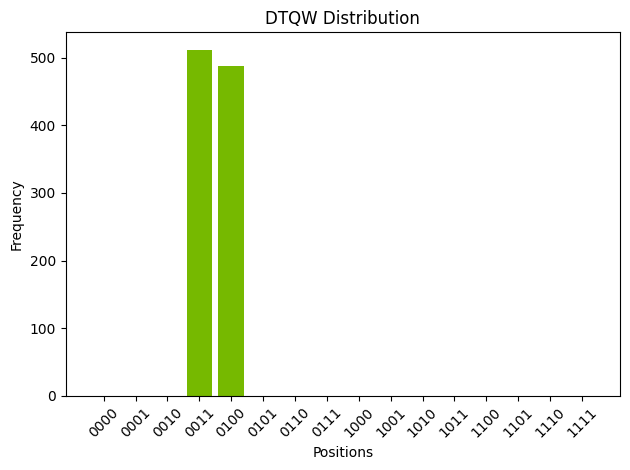

In [ ]:
# Set the number of qubits
num_qubits = 4
@cudaq.kernel
def DTQW_one_step(num_qubits: int):
    walker_qubits = cudaq.qvector(num_qubits)
    coin_qubit = cudaq.qubit()
    endpoint_qubit = cudaq.qubit()

    # Initial walker state 1/(sqrt{2}) ( |2>+|3>)
    initial_position(walker_qubits)

    # Initial coin state
    h(coin_qubit) #Comment to set the initial coin state to be |0>

    # One quantum walk step
    # Coin operation F=H
    h(coin_qubit)

    # Walker's position change

    ## Shifting right

    # Avoid shifting from |1111> to |0000> in case the coin is |1> by flipping the coin to |0>
    no_INC_at_right_endpoint(walker_qubits, coin_qubit, endpoint_qubit)

    # Shift right (S+) when the coin is |1> and the walker is not in the |1111> state
    #INC.ctrl(coin_qubit, walker_qubits[0], walker_qubits[1], walker_qubits[2], walker_qubits[3])
    cudaq.control(inc, coin_qubit, walker_qubits)

    # Reset the coin and endpoints in case they were changed to avoid moving from |1111> to |0000>
    reset_coin_and_endpoint(coin_qubit, endpoint_qubit)

    ## Shifting left

    # Avoid shifting from |0000> to |1111> in case the coin is |0> by flipping the coin to |1>
    no_DEC_at_left_endpoint(walker_qubits, coin_qubit, endpoint_qubit)

    # Shift left (S-) when the coin is |0>
    # EDIT CODE BELOW THIS LINE
    x(coin_qubit)
    #DEC.ctrl(coin_qubit, walker_qubits[0], walker_qubits[1], walker_qubits[2], walker_qubits[3])
    cudaq.control(dec, coin_qubit, walker_qubits)
    x(coin_qubit)

    # EDIT CODE ABOVE THIS LINE

    # Reset the coin and endpoints in case they were changed to avoid moving from |0000> to |1111>
    reset_coin_and_endpoint(coin_qubit, endpoint_qubit)


# Visualize the kernel for the quantum walk
#print(cudaq.draw(DTQW_one_step, num_qubits))

result = cudaq.sample(DTQW_one_step, num_qubits, shots_count=1000)

# defines indices for walker_qubits_register
walker_register = list(range(0, num_qubits))

walker_register_marginal_counts = result.get_marginal_counts(walker_register)

print(walker_register_marginal_counts)

#plot_results(walker_register_marginal_counts, num_qubits)
plot_walk_results(walker_register_marginal_counts, num_qubits, "DTQW Distribution")

### Multi-Split Step Quantum Walk

In [ ]:
# Initialize the quantum walk kernel and position shift
# Fixed variables do not change
num_qubits = 4 # Number of qubits representing the state of the walker

# Variables that you can experiment with
num_investors = 2 # Number of investors
num_time_steps = 2 # Number of repetitions of the Investors' walk
shots_count = 10000

@cudaq.kernel
def multiSSQW_kernel(num_qubits: int, num_investors: int, num_time_steps : int, param : list[float]):
    """ kernel for the multi-SSQW circuit for num_investors and num_time_steps
    Parameters
        num_qubits : int
        Number of qubits for the walker's state

        num_investors : int
        Number of split-step pairs in one time step

        num_time_steps : int
        Number of iterations of the investor's split steps

        param : list[float]
        Parameters for the coin operators
    """
    walker_qubits = cudaq.qvector(num_qubits)
    coin_qubit = cudaq.qubit()
    endpoint_qubit = cudaq.qubit()
    # Initial walker state |0101>
    x(walker_qubits[1])
    x(walker_qubits[3])

    for _ in range(num_time_steps):
        # Quantum walk split steps of all the investors
        for k in range(num_investors):
            # Split step of one investor


            # First coin operation
            u3(param[(k+1)*6-3], param[(k+1)*6-2], param[(k+1)*6-1], coin_qubit)

            # Walker's position change
            # Avoid shifting from |1111> to |0000> in case the coin is |1> by flipping the coin to |0>
            no_INC_at_right_endpoint(walker_qubits, coin_qubit, endpoint_qubit)
            # Shift to the right if the coin is |1> and the position is not |1111>
            cudaq.control(inc, coin_qubit, walker_qubits)

            # Reset the coin and endpoints in case they were changed to avoid moving from |1111> to |0000>
            reset_coin_and_endpoint(coin_qubit, endpoint_qubit)


            # Second coin operation
            u3(param[(k+1)*6], param[(k+1)*6+1], param[(k+1)*6+2], coin_qubit)

            # Controlled-decrementer
            # Avoid shifting from |0000> to |1111> in case the coin is |0> by flipping the coin to |1>
            no_DEC_at_left_endpoint(walker_qubits, coin_qubit, endpoint_qubit)

            # Apply the DEC if the the coin is in |0>
            x(coin_qubit)
            cudaq.control(dec, coin_qubit, walker_qubits)
            x(coin_qubit)

            # Reset the coin and endpoints in case they were changed to avoid moving from |0000> to |1111>
            reset_coin_and_endpoint(coin_qubit, endpoint_qubit)


In [ ]:
def quantum_walk_simulation(kernel, num_qubits, num_investors, num_time_steps, param, shots_count=shots_count):
    """
    Execute the multi-SSQW kernel with the given parameters and return probabilities.

    Parameters
        kernel : cudaq.kernel parameterized kernel to be sampled
        num_qubits, num_investors, num_time_steps: parameters defining the kernel
        param : float values for the gate parameters in the kernel
        shots_count : int, number of shots for sampling

    Returns
        probs : list
        A list of float probabilities sorted by bitstring (e.g., [P(00..0), ..., P(11..1)])
    """
    #    Sample the kernel (Measures all qubits by default)
    #    Returns a SampleResult object (dictionary of counts)
    full_result = cudaq.sample(kernel, num_qubits, num_investors, num_time_steps, param, shots_count=shots_count)

    #   Extract marginal counts for the first `num_qubits`
    #    This isolates the position register (indices 0 to num_qubits-1)
    #    and discards the states of coin or endpoint qubits.
    target_indices = list(range(num_qubits))
    marginal_counts = full_result.get_marginal_counts(target_indices)

    #    Initialize dictionary with ALL possible bitstrings
    #    This ensures the output list is fully populated (including 0s) and sorted.
    result_dictionary = {}
    for i in range(2**num_qubits):
        bitstr = bin(i)[2:].zfill(num_qubits)
        result_dictionary[bitstr] = 0

    #  Update with actual data from marginal counts
    for bitstr, count in marginal_counts.items():
        # Robust cleanup: remove any potential invisible characters/spaces
        clean_key = "".join(c for c in str(bitstr) if c in "01")

        if clean_key in result_dictionary:
            result_dictionary[clean_key] = count

    #   Convert counts to a list of probabilities
    #    Sort by keys to ensure the list order matches the histogram x-axis (000, 001, 010...)
    sorted_keys = sorted(result_dictionary.keys())
    probs = [result_dictionary[key] / shots_count for key in sorted_keys]

    return probs


def optimize_distribution(kernel, num_qubits, num_investors, num_time_steps, target, max_iter=100):
    """
    Optimize the quantum walk parameters to match the target distribution
    """
    errors = []
    best_error, best_params = float('inf'), None

    # Define the cost function as a mean square error between the results of the sampling of the kernel
    # with given parameters and the targeted distribution
    def cost_function(params):
        trained = quantum_walk_simulation(kernel, num_qubits, num_investors, num_time_steps, params)
        return np.mean((trained - target)**2)

    def callback(xk):
        errors.append(cost_function(xk))

    # Randomly initialize parameters
    random.seed(42)
    x0 = [random.uniform(0, np.pi) for _ in range(6*num_investors + 3)]


    # Optimize
    result = minimize(cost_function, x0=x0, method="COBYLA", options={'maxiter': max_iter}, callback=callback )
    if result.fun < best_error:
        best_error = result.fun
        best_params = result.x

    print(f"Current best error: {best_error}")

    return best_params, errors, best_error

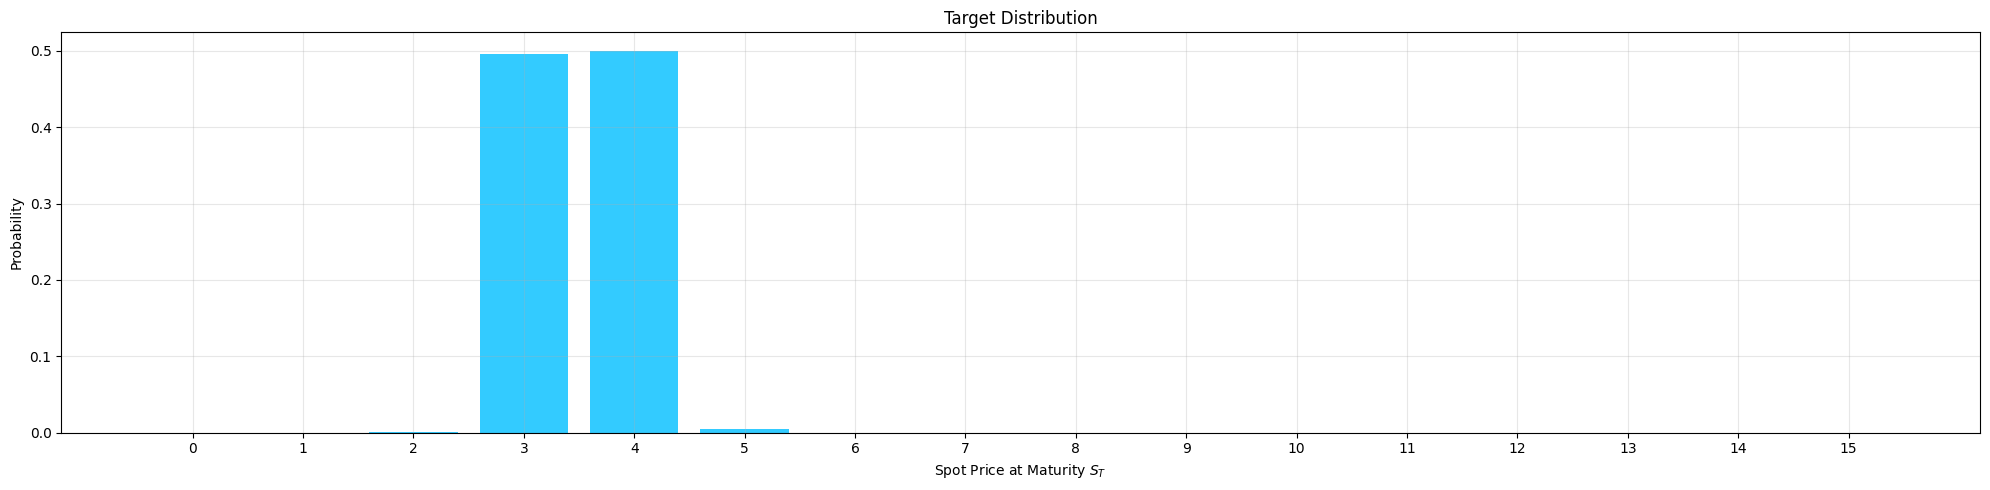

In [ ]:
# Prepare data

S = 4.0  # initial spot price
vol = 0.3  # volatility (40%)
r = 0.06  # annual interest rate (4%)
T = 30 / 365  # 90 days to maturity


def prepare_data(S, vol, r, T, num_qubits=4):
    mu = (r - 0.5 * vol**2) * T + np.log(S)
    sigma = vol * np.sqrt(T)

    N = 50000  # more stable sampling

    samples = np.random.lognormal(mean=mu, sigma=sigma, size=N)

    # map continuous values into discrete bins [0, 2^n - 1]
    max_val = 2**num_qubits - 1
    scaled = np.clip(np.floor(samples), 0, max_val).astype(int)

    target = np.bincount(scaled, minlength=max_val + 1)
    return target / np.sum(target)


target = prepare_data(S, vol, r, T)

# Plot the target distribution
fig, ax1 = plt.subplots(figsize=(20, 5))  # Increased figure width to accommodate all ticks

# Quantum walk vs. target distribution comparison
x = np.arange(len(target))
ax1.bar(x, target, color='#00BFFF', alpha=0.8)
ax1.set(title='Target Distribution', xlabel='Spot Price at Maturity $S_T$', ylabel='Probability')
ax1.set_xticks(np.arange(len(target)))
ax1.tick_params(axis='x', which='major', labelbottom=True)
ax1.grid(alpha=0.3)

plt.tight_layout()  # Use this to avoid labels and titles being cut off
plt.show()

In [ ]:
# Define the simulation target
cudaq.set_target("qpp-cpu") #for simulation on CPU
#cudaq.set_target("nvidia") #for simulation on GPU
# If you run on a GPU, up the shots_count=10000 for a more accurate simulation
# you can also increase the number of iterations to 200

# Optimize to get the final distribution
best_params, errors, final_error = optimize_distribution(multiSSQW_kernel, num_qubits, num_investors, num_time_steps, target)

def run_experiment(num_qubits, num_investors, num_time_steps, target):
    best_params, errors, final_error = optimize_distribution(
        multiSSQW_kernel,
        num_qubits,
        num_investors,
        num_time_steps,
        target
    )
    # Simulate the quantum walk with the best parameters
    qw = quantum_walk_simulation(multiSSQW_kernel, num_qubits, num_investors, num_time_steps, best_params)

    return qw, best_params, final_error, errors

Current best error: 0.00238530445


### Optimization

In [ ]:
#Grid search
results = []

for investors in range(1, 5):          # try 1–4 walkers
    for steps in range(1, 6):          # try 1–5 time steps

        qw_dist, params, error, errors = run_experiment(
            num_qubits,
            investors,
            steps,
            target
        )

        results.append({
            "investors": investors,
            "steps": steps,
            "error": error,
            "params": params
        })

        print(f"Investors={investors}, Steps={steps}, Error={error}")

Current best error: 0.020474170700000002
Investors=1, Steps=1, Error=0.020474170700000002
Current best error: 0.0033066502
Investors=1, Steps=2, Error=0.0033066502
Current best error: 0.006576499199999999
Investors=1, Steps=3, Error=0.006576499199999999
Current best error: 0.00686122945
Investors=1, Steps=4, Error=0.00686122945
Current best error: 0.010089088699999998
Investors=1, Steps=5, Error=0.010089088699999998
Current best error: 3.0774500000000026e-06
Investors=2, Steps=1, Error=3.0774500000000026e-06
Current best error: 0.0031299586999999993
Investors=2, Steps=2, Error=0.0031299586999999993
Current best error: 0.003699249449999999
Investors=2, Steps=3, Error=0.003699249449999999
Current best error: 0.004735141949999999
Investors=2, Steps=4, Error=0.004735141949999999
Current best error: 0.011837169199999999
Investors=2, Steps=5, Error=0.011837169199999999
Current best error: 0.005481522199999998
Investors=3, Steps=1, Error=0.005481522199999998
Current best error: 0.00419309395


In [ ]:
#Finding best configuration
best_result = min(results, key=lambda x: x["error"])

print("\nBest configuration:")
print(best_result)


Best configuration:
{'investors': 2, 'steps': 1, 'error': np.float64(3.0774500000000026e-06), 'params': array([ 2.90495666,  1.70683713,  0.04547475,  0.05574998,  1.75296028,
        0.83426657,  6.49742077,  0.72078873,  2.37857845, -0.04989376,
        2.99217291,  1.13334546, -1.5837035 , -0.57440698,  1.63950751])}


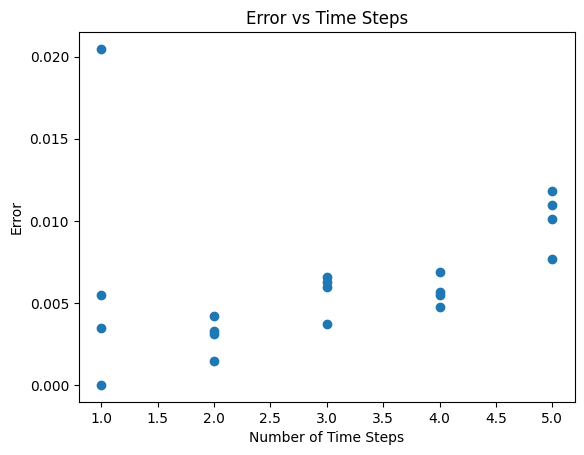

In [ ]:
#Plot performance vs parameters
steps_list = [r["steps"] for r in results]
errors_list = [r["error"] for r in results]

plt.scatter(steps_list, errors_list)
plt.xlabel("Number of Time Steps")
plt.ylabel("Error")
plt.title("Error vs Time Steps")
plt.show()

In [ ]:
qw, best_params, final_error, errors = run_experiment(
    num_qubits,
    best_result["investors"],
    best_result["steps"],
    target
)

Current best error: 2.549449999999991e-06


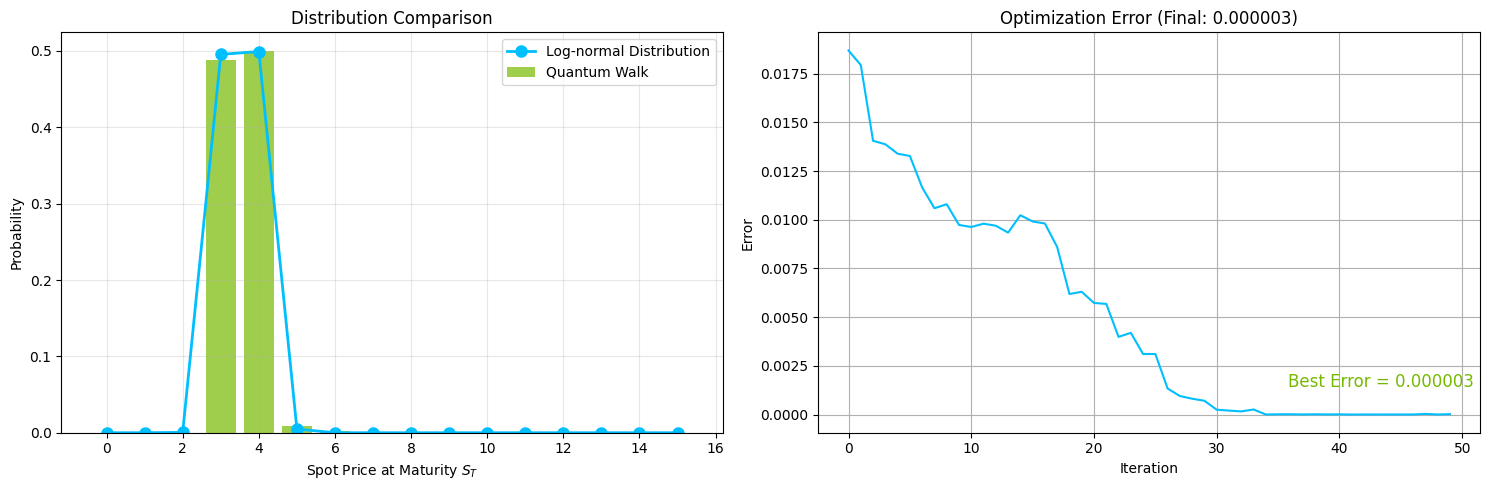

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Quantum walk vs. target distribution comparison
x = np.arange(len(target))
ax1.bar(x, qw, width=0.8, color='#76B900', alpha=0.7, label='Quantum Walk')
ax1.plot(x, target, '-o', color='#00BFFF', linewidth=2, markersize=8, label='Log-normal Distribution')
ax1.set(title='Distribution Comparison', xlabel='Spot Price at Maturity $S_T$', ylabel='Probability')
ax1.grid(alpha=0.3)
ax1.legend()

# Optimization errors plot
ax2.plot(errors, label='Error', color = '#00BFFF')
ax2.set(title=f'Optimization Error (Final: {final_error:.6f})', xlabel='Iteration', ylabel='Error')
ax2.grid(True)
ax2.annotate(f'Best Error = {final_error:.6f}', xy=(len(errors)-1, final_error), xytext=(-50, 20),
             textcoords='offset points', ha='center', fontsize=12, color='#76B900')

plt.tight_layout()
plt.show()

### Stock Market Data Implementation

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

In [ ]:
apple = yf.Ticker("AAPL")
data = apple.history(period="1mo")
prices = data["Close"].values
returns = np.diff(np.log(prices))

def prepare_real_data(returns, num_qubits):
    num_bins = 2**num_qubits

    # Normalize returns into range [0, num_bins-1]
    min_r, max_r = returns.min(), returns.max()

    scaled = (returns - min_r) / (max_r - min_r)
    indices = np.floor(scaled * (num_bins - 1)).astype(int)

    # Build histogram
    counts = np.bincount(indices, minlength=num_bins)

    return counts / counts.sum()

target = prepare_real_data(returns, num_qubits)

In [ ]:
print("Target distribution (first 10 bins):", target[:10])
print("Sum of probabilities:", np.sum(target))

Target distribution (first 10 bins): [0.05 0.05 0.   0.1  0.05 0.05 0.1  0.15 0.1  0.05]
Sum of probabilities: 1.0


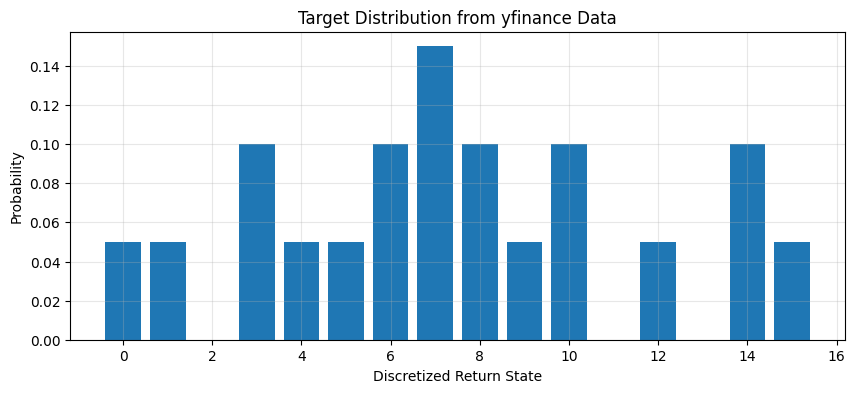

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(target)), target)
plt.title("Target Distribution from yfinance Data")
plt.xlabel("Discretized Return State")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.show()

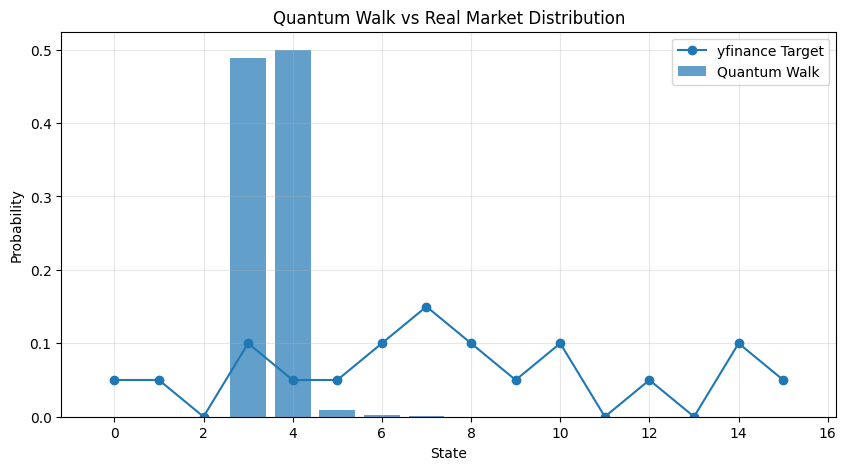

In [ ]:
x = np.arange(len(target))

plt.figure(figsize=(10, 5))
plt.bar(x, qw, alpha=0.7, label="Quantum Walk")
plt.plot(x, target, '-o', label="yfinance Target")
plt.legend()
plt.title("Quantum Walk vs Real Market Distribution")
plt.xlabel("State")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.show()